In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("data/sncf_retards.csv", sep=";", encoding="utf-8-sig")
print(f"Shape initiale: {df.shape}")
df.head()

Shape initiale: (12181, 26)


,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,...,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141,870,5,NaN,289,11.247809,...,110,6.511118,44,8,36.134454,31.092437,10.924370,15.966387,5.042017,0.840336
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56,406,1,NaN,213,8.479969,...,32,5.363539,9,4,20.000000,35.000000,16.666667,16.666667,8.333333,3.333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166,226,0,NaN,21,6.239683,...,11,2.938053,6,1,22.222222,27.777778,16.666667,16.666667,5.555556,11.111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,124,508,3,NaN,71,7.235211,...,39,5.292211,18,8,33.333333,22.222222,16.666667,20.370370,5.555556,1.851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94,472,4,NaN,224,6.784673,...,42,4.882372,10,0,15.789474,45.614035,19.298246,15.789474,1.754386,1.754386


In [3]:
import os
print(os.getcwd())
print(os.path.exists("../data/sncf_retards.csv"))
print(os.listdir(".."))

/Users/lennys/Documents/ml-poc-project
False
['film-tracker', 'DeeKeep', '.DS_Store', 'ExitUpsellKeyValueStore', 'Micro-Entreprise.png', '.localized', 'ml-poc-project', 'Mon dossier Tableau', 'Résultat de Terminal.txt', 'prom voltaire.jpg', 'Document_de_Synthese_J00133827246_v1-2.pdf']


In [5]:
col_dep = [c for c in df.columns if c.startswith("Gare de d")][0]
col_arr = [c for c in df.columns if "Gare" in c and "arriv" in c.lower()][0]
target = [c for c in df.columns if "Retard moyen de tous les trains" in c and "arriv" in c][0]
col_duree = [c for c in df.columns if "moyenne du trajet" in c][0]
col_circ = [c for c in df.columns if "circulations" in c][0]
col_annul = [c for c in df.columns if "annul" in c.lower() and "Nombre" in c][0]
col_retard_dep = [c for c in df.columns if "Retard moyen de tous les trains" in c and "part" in c.lower()][0]
cause_cols = [c for c in df.columns if c.startswith("Prct retard")]

print(f"Target: {target}")
print(f"Retard depart: {col_retard_dep}")
print(f"Causes: {len(cause_cols)} colonnes")

cols_drop = [c for c in df.columns if "Commentaire" in c] + ["Service"]
df = df.drop(columns=cols_drop)

df["Annee"] = df["Date"].str[:4].astype(int)
df["Mois"] = df["Date"].str[5:7].astype(int)
df = df.drop(columns=["Date"])

df = df[df[target] >= 0]
print(f"Apres nettoyage: {df.shape}")

Target: Retard moyen de tous les trains à l'arrivée
Retard depart: Retard moyen de tous les trains au départ
Causes: 6 colonnes
Apres nettoyage: (12061, 23)


In [6]:
df["taux_annulation"] = df[col_annul] / df[col_circ] * 100

df["mois_sin"] = np.sin(2 * np.pi * df["Mois"] / 12)
df["mois_cos"] = np.cos(2 * np.pi * df["Mois"] / 12)

col_nb_retard_dep = [c for c in df.columns if "Nombre de trains en retard au d" in c][0]
df["pct_retard_depart"] = df[col_nb_retard_dep] / df[col_circ] * 100

le_dep = LabelEncoder()
le_arr = LabelEncoder()
df["gare_dep_enc"] = le_dep.fit_transform(df[col_dep])
df["gare_arr_enc"] = le_arr.fit_transform(df[col_arr])

joblib.dump(le_dep, "models/le_depart.joblib")
joblib.dump(le_arr, "models/le_arrivee.joblib")

for c in cause_cols:
    df[c] = df[c].fillna(0)

print("Features creees avec succes")
print(f"Shape finale: {df.shape}")

Features creees avec succes
Shape finale: (12061, 29)


In [8]:
features_v1 = [
    "gare_dep_enc", "gare_arr_enc", col_duree,
    col_circ, col_annul, "Annee", "Mois",
]

features_v2 = [
    "gare_dep_enc", "gare_arr_enc", col_duree,
    col_circ, col_annul, "Annee",
    "mois_sin", "mois_cos",
    "taux_annulation",
    col_retard_dep,
    "pct_retard_depart",
] + cause_cols

print(f"V1: {len(features_v1)} features")
print(f"V2: {len(features_v2)} features")
print(f"\nNouvelles features ajoutees:")
for f in features_v2:
    if f not in features_v1:
        print(f"  + {f}")

V1: 7 features
V2: 17 features

Nouvelles features ajoutees:
  + mois_sin
  + mois_cos
  + taux_annulation
  + Retard moyen de tous les trains au départ
  + pct_retard_depart
  + Prct retard pour causes externes
  + Prct retard pour cause infrastructure
  + Prct retard pour cause gestion trafic
  + Prct retard pour cause matériel roulant
  + Prct retard pour cause gestion en gare et réutilisation de matériel
  + Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)


In [10]:
# Nettoyer tous les NaN dans les features V2
for col in features_v2:
    df[col] = df[col].fillna(0)

print(f"NaN restants dans features V2: {df[features_v2].isnull().sum().sum()}")

NaN restants dans features V2: 0


In [12]:
# Remplacer les infinis et NaN dans tout le dataframe
df = df.replace([np.inf, -np.inf], 0)
df = df.fillna(0)

print(f"NaN restants: {df[features_v2].isnull().sum().sum()}")
print(f"Inf restants: {np.isinf(df[features_v2].values).sum()}")

NaN restants: 0
Inf restants: 0


In [13]:
y = df[target]

results = []

for version, features in [("V1 (ancien)", features_v1), ("V2 (enrichi)", features_v2)]:
    X = df[features]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, random_state=42)
    gb.fit(X_train, y_train)
    y_pred = gb.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({"Version": version, "Features": len(features), "MAE": mae, "RMSE": rmse, "R2": r2})
    print(f"{version}: MAE={mae:.2f} | RMSE={rmse:.2f} | R2={r2:.4f}")

print("\n" + "="*60)
improvement = results[1]["R2"] - results[0]["R2"]
print(f"Amelioration du R2: +{improvement:.4f} ({improvement*100:.1f} points)")

V1 (ancien): MAE=1.89 | RMSE=2.74 | R2=0.5038
V2 (enrichi): MAE=1.44 | RMSE=2.14 | R2=0.6970

Amelioration du R2: +0.1932 (19.3 points)


In [14]:
X = df[features_v2]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [4, 5, 6, 7],
    "learning_rate": [0.05, 0.1, 0.15],
    "min_samples_leaf": [5, 10, 20],
}

print("GridSearchCV en cours (ca peut prendre 2-3 minutes)...")
grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=0,
)
grid.fit(X_train, y_train)

print(f"\nMeilleurs parametres: {grid.best_params_}")
print(f"Meilleur R2 (CV): {grid.best_score_:.4f}")

y_pred = grid.best_estimator_.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nPerformance sur le test set:")
print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f}")

GridSearchCV en cours (ca peut prendre 2-3 minutes)...

Meilleurs parametres: {'learning_rate': 0.15, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 500}
Meilleur R2 (CV): 0.6485

Performance sur le test set:
MAE: 1.47 | RMSE: 2.21 | R2: 0.6790


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    df[features_v2], y, test_size=0.2, random_state=42
)

best_params = grid.best_params_

models = {
    "linear_regression": LinearRegression(),
    "random_forest": RandomForestRegressor(n_estimators=300, max_depth=7, random_state=42, n_jobs=-1),
    "gradient_boosting": GradientBoostingRegressor(**best_params, random_state=42),
    "knn": Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsRegressor(n_neighbors=10))]),
}

print(f"{'Modele':<25} {'MAE':>8} {'RMSE':>8} {'R2':>8}")
print("-" * 55)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"{name:<25} {mae:>8.2f} {rmse:>8.2f} {r2:>8.4f}")
    
    joblib.dump(model, f"models/{name}.joblib")

print("\nTous les modeles sauvegardes.")

Modele                         MAE     RMSE       R2
-------------------------------------------------------
linear_regression             2.36     3.58   0.1523
random_forest                 1.80     2.62   0.5486
gradient_boosting             1.47     2.21   0.6790
knn                           2.02     2.82   0.4745

Tous les modeles sauvegardes.


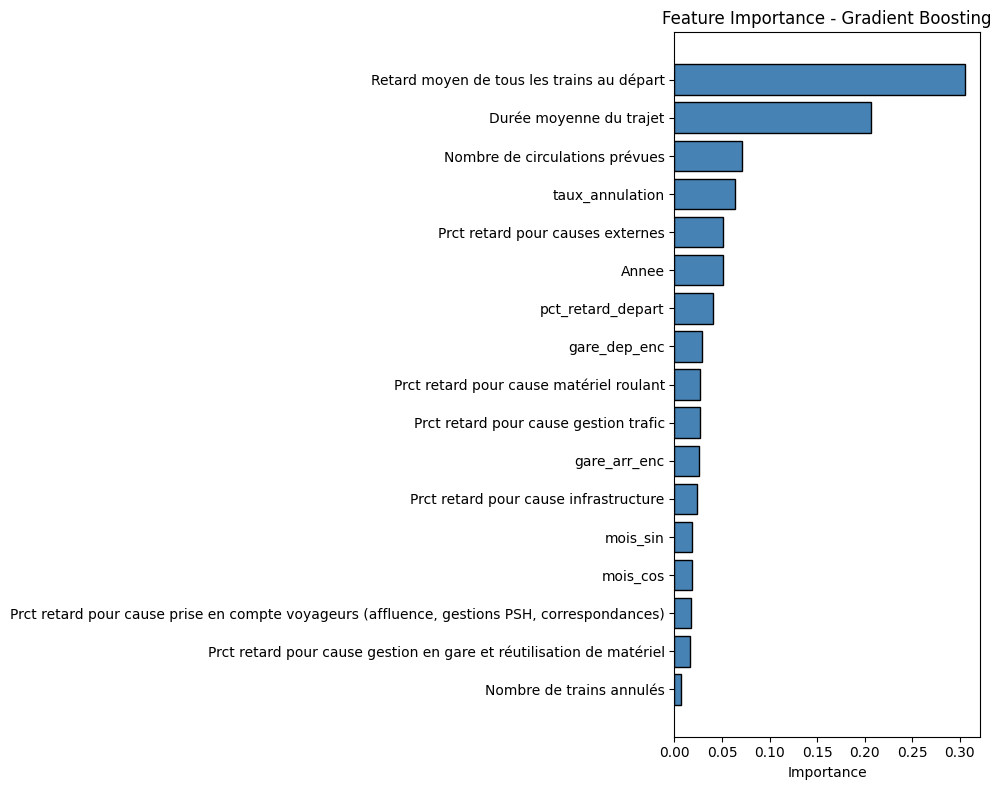

In [16]:
import matplotlib.pyplot as plt

best_gb = models["gradient_boosting"]
importances = best_gb.feature_importances_
feat_imp = pd.DataFrame({
    "Feature": features_v2,
    "Importance": importances
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(feat_imp["Feature"], feat_imp["Importance"], color="steelblue", edgecolor="black")
ax.set_xlabel("Importance")
ax.set_title("Feature Importance - Gradient Boosting")
plt.tight_layout()
plt.show()